# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes
- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---

### Bibliotecas

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
import tensorflow as tf

2025-11-18 15:12:45.651093: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-18 15:12:45.986241: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 15:12:47.517584: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---

### Data:

In [3]:
data_folder = Path("../../data/classification/")
# original_folder = data_folder / "original"
processed_folder = data_folder / "processed"

In [4]:
# Metadata
metadata_df = pd.read_csv(processed_folder / "galaxy_morphology.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,3,S
1,4,S
2,6,S
3,7,S
4,13,E


In [5]:
# Files
processed_images = np.load(processed_folder / "processed_images.npz")
files = processed_images.files
print(files[:10])

['3', '4', '6', '7', '13', '19', '20', '30', '32', '33']


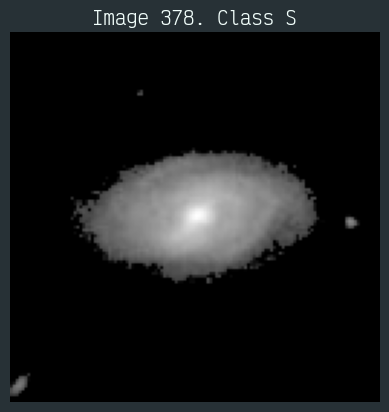

In [6]:
# Ejemplo
img_name = files[119]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

---

### Modelo 1. CNN:

In [ ]:
input_size = 2
output_size = 1

model = tf.keras.Sequential([tf.keras.layers.Dense(output_size)])

model.compile(optimizer="sgd", loss="mean_squared_error")

model.fit(metadata_df["class"], processed_images, epochs=100, verbose="")